In [1]:
import pandas as pd
pd.set_option('display.max_columns', 10)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, HTML
import re
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize
from sklearn.pipeline import Pipeline
import joblib

In [2]:
df =pd.read_parquet('books.parquet')
df = df.sample(frac=0.6)
data  = df.copy()
df.shape

(15000, 25)

In [3]:
#info
df.info()

<class 'pandas.DataFrame'>
Index: 15000 entries, 11433 to 19504
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            15000 non-null  str    
 1   title             15000 non-null  str    
 2   series            7339 non-null   str    
 3   author            15000 non-null  str    
 4   rating            15000 non-null  float64
 5   description       14539 non-null  str    
 6   language          13651 non-null  str    
 7   isbn              15000 non-null  str    
 8   genres            15000 non-null  str    
 9   characters        15000 non-null  str    
 10  bookFormat        14515 non-null  str    
 11  edition           1463 non-null   str    
 12  pages             14155 non-null  str    
 13  publisher         13724 non-null  str    
 14  publishDate       14755 non-null  str    
 15  firstPublishDate  8252 non-null   str    
 16  awards            15000 non-null  str    
 17  numRa

In [4]:
# null values can be seen, let's check
df.isna().sum()

bookId                  0
title                   0
series               7661
author                  0
rating                  0
description           461
language             1349
isbn                    0
genres                  0
characters              0
bookFormat            485
edition             13537
pages                 845
publisher            1276
publishDate           245
firstPublishDate     6748
awards                  0
numRatings              0
ratingsByStars          0
likedPercent          232
setting                 0
coverImg              204
bbeScore                0
bbeVotes                0
price                4796
dtype: int64

In [5]:
#head
df.head(2)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
11433,20176552-dragon-age-volume-1,"Dragon Age, Volume 1",Dragon Age Graphic Novels #1-3,"David Gaider, Chad Hardin (Illustrator), Antho...",4.26,...,[],https://i.gr-assets.com/images/S/compressed.ph...,91,1,141.20
17024,18840.The_Common_Reader,The Common Reader,NaN,"Virginia Woolf, Andrew McNeillie (Editor)",4.17,...,[],https://i.gr-assets.com/images/S/compressed.ph...,54,1,5.76


In [6]:
#duplicates by title and author
df.duplicated(subset= [ 'title' , 'author']).sum()

np.int64(19)

In [7]:
#check those duplicates
df[df.duplicated(subset= [ 'title' , 'author'])]

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
4733,1481056.Gifts_and_Ministries_of_the_Holy_Spirit,Gifts and Ministries of the Holy Spirit,NaN,Lester Sumrall,4.44,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,5.00
329,17839844-simply-infiltrating-thought-you-will-...,"SIMPLY INFILTRATING THOUGHT ""You Will Only Und...",NaN,"Creative Success Coach, Nkosi N. Guduza",5.00,...,[],https://i.gr-assets.com/images/S/compressed.ph...,99,1,28.79
4027,27223433-limits-of-destiny,Limits of Destiny,Limits of Destiny #4,Sharlyn G. Branson (Goodreads Author),4.47,...,[],https://i.gr-assets.com/images/S/compressed.ph...,190,2,NaN
20180,17337543-the-game-changer,The Game Changer,The Game Changer #1,L.M. Trio (Goodreads Author),4.12,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,NaN
1923,22372599-the-seahorse-legacy,The Seahorse Legacy,Eyes of E'veria #3,Serena Chase (Goodreads Author),4.64,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,NaN
24283,15741217-writing-scary-scenes,Writing Scary Scenes,Writer's Craft #2,Rayne Hall,4.06,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,NaN
8466,26008216-limits-of-destiny,Limits of Destiny,Limits of Destiny #2,Sharlyn G. Branson (Goodreads Author),4.32,...,[],https://i.gr-assets.com/images/S/compressed.ph...,194,2,NaN
10994,975953.Time_of_the_Dragons,Time of the Dragons,Shike #1,Robert Shea,4.27,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,5.45
20866,17406982,আমি এবং আমরা,মিসির আলি #10,Humayun Ahmed,4.11,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,NaN
347,23466526-mute,Mute: Poems That Saved My Life!: Poems by Vidy...,NaN,Vidya Gargote,5.00,...,[],NaN,99,1,13.60


In [8]:
#drop duplicates
df.drop_duplicates(subset= [ 'title' , 'author'], keep = 'first', inplace = True)

# EDA

In [9]:
# all categorical columns
df.select_dtypes(include = ['str','object']).head(2)

,bookId,title,series,author,description,...,awards,ratingsByStars,setting,coverImg,price
11433,20176552-dragon-age-volume-1,"Dragon Age, Volume 1",Dragon Age Graphic Novels #1-3,"David Gaider, Chad Hardin (Illustrator), Antho...",Helping set the stage for BioWare's hotly anti...,...,[],"['253', '201', '85', '10', '1']",[],https://i.gr-assets.com/images/S/compressed.ph...,141.20
17024,18840.The_Common_Reader,The Common Reader,NaN,"Virginia Woolf, Andrew McNeillie (Editor)",Woolf's first and most popular volume of essay...,...,[],"['600', '511', '232', '45', '13']",[],https://i.gr-assets.com/images/S/compressed.ph...,5.76


In [10]:
# columns : pages and price are of string types where as it should be numerical,
df['pages'] = pd.to_numeric(df['pages'], errors = 'coerce') #pages will be converted to float
df['price'] = pd.to_numeric(df['price'], errors = 'coerce') #price will be converted to float

In [11]:
# numerical columns
df.select_dtypes(include = ['number']).head(2)

,rating,pages,numRatings,likedPercent,bbeScore,bbeVotes,price
11433,4.26,227.0,550,98.0,91,1,141.20
17024,4.17,272.0,1401,96.0,54,1,5.76


In [12]:
# Let's plot images of the top 30 books with highest liked percentage

# Collect valid image URLs in a list

display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 30 Books by Highest Liked Percentage</h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/>"
        f"<div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='likedPercent', ascending=False).head(30)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [13]:
# Let's plot images of the top 30 books with lowest likedPercent

# Collect valid image URLs in a list

display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 30 Books by Lowest Liked Percentage</h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/>"
        f"<div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='likedPercent').head(30)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [14]:
df['bookFormat'].value_counts()

bookFormat
Paperback                7287
Hardcover                3315
Kindle Edition           2038
ebook                     860
Mass Market Paperback     672
                         ... 
Gebundene Ausgabe           1
hardback                    1
revised edition             1
Podiobook                   1
Novelty Book                1
Name: count, Length: 74, dtype: int64

In [15]:
# plotting 20 most expensive books
display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 20 Most Expensive Books </h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/><div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='price', ascending=False).head(20)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [16]:
df.sort_values(by='price', ascending=True).head(20)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
22389,1079378.When_I_Loved_Myself_Enough,When I Loved Myself Enough,NaN,Kim McMillen,4.09,...,[],https://i.gr-assets.com/images/S/compressed.ph...,32,1,0.84
20303,3713102-kiss-of-fate,Kiss of Fate,Dragonfire #3,Deborah Cooke (Goodreads Author),4.12,...,[],https://i.gr-assets.com/images/S/compressed.ph...,61,1,0.84
16763,1014792.The_State_of_Africa,The State of Africa: A History of Fifty Years ...,NaN,Martin Meredith,4.17,...,[],https://i.gr-assets.com/images/S/compressed.ph...,96,1,0.84
9546,305439.River_s_Edge,River's Edge,Cape Refuge #3,Terri Blackstock (Goodreads Author),4.30,...,[],https://i.gr-assets.com/images/S/compressed.ph...,90,1,0.84
8237,17853024-the-pagan-lord,The Pagan Lord,The Last Kingdom #7,Bernard Cornwell (Goodreads Author),4.33,...,[],https://i.gr-assets.com/images/S/compressed.ph...,81,1,0.84
21616,661283.Manhood,Manhood,NaN,Steve Biddulph,4.10,...,[],https://i.gr-assets.com/images/S/compressed.ph...,74,1,0.84
14304,11961425-toba-tek-singh,Toba Tek Singh: Stories,NaN,"Saadat Hasan Manto, Khalid Hasan (Translator)",4.21,...,[],https://i.gr-assets.com/images/S/compressed.ph...,89,1,0.84
15480,308532.Soft_Target,Soft Target,Dan Shepherd #2,Stephen Leather (Goodreads Author),4.19,...,[],https://i.gr-assets.com/images/S/compressed.ph...,94,1,0.84
20195,1264696.Evermore,Evermore,Darkyn #5,Lynn Viehl,4.12,...,['United States of America'],https://i.gr-assets.com/images/S/compressed.ph...,85,1,0.84
22130,381817.False_Gods,False Gods,The Horus Heresy #2,Graham McNeill,4.09,...,[],https://i.gr-assets.com/images/S/compressed.ph...,95,1,0.84


In [17]:
# plotting 20 least expensive books
display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 20 Least Expensive Books </h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/><div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='price', ascending=True).head(20)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


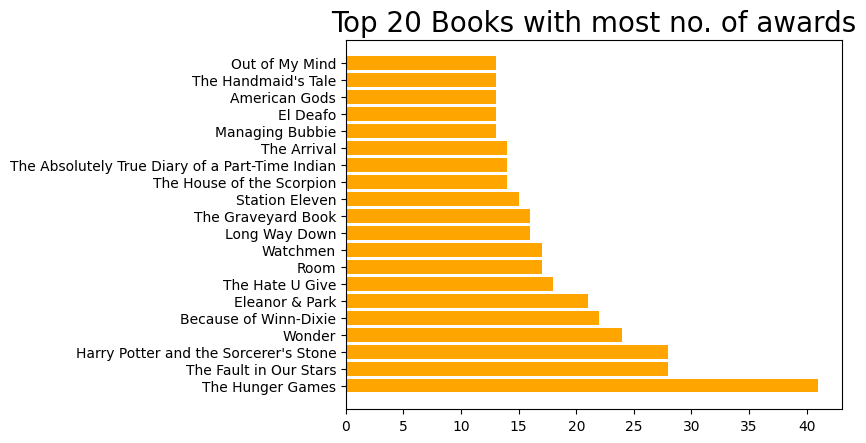

In [18]:
# Get titles and award counts for the top 20 books with most awards
no_of_awards = df['awards'].str.replace('[','').str.replace(']','').str.split(',').apply(lambda lst: len([x.strip() for x in lst if x.strip() != ''])).sort_values(ascending = False).head(20)
ax = plt.barh(width= no_of_awards.values, y = df.loc[no_of_awards.index,'title'], color = 'orange')
plt.plot(figsize = (10,10), ax =ax)
plt.title('Top 20 Books with most no. of awards', size = 20);



In [19]:
df.language.value_counts()

language
English                        12035
Arabic                           198
Spanish                          189
French                           135
German                           125
                               ...  
English, Middle (1100-1500)        1
Telugu                             1
Malayalam                          1
Afrikaans                          1
Latvian                            1
Name: count, Length: 62, dtype: int64

# Feature Engineering

In [20]:
df.head(2)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
11433,20176552-dragon-age-volume-1,"Dragon Age, Volume 1",Dragon Age Graphic Novels #1-3,"David Gaider, Chad Hardin (Illustrator), Antho...",4.26,...,[],https://i.gr-assets.com/images/S/compressed.ph...,91,1,141.20
17024,18840.The_Common_Reader,The Common Reader,NaN,"Virginia Woolf, Andrew McNeillie (Editor)",4.17,...,[],https://i.gr-assets.com/images/S/compressed.ph...,54,1,5.76


In [21]:
# we will use only few columns
df = df[['title','author','description','genres', 'coverImg']]
df.head()

,title,author,description,genres,coverImg
11433,"Dragon Age, Volume 1","David Gaider, Chad Hardin (Illustrator), Antho...",Helping set the stage for BioWare's hotly anti...,"['Fantasy', 'Comics', 'Graphic Novels', 'Video...",https://i.gr-assets.com/images/S/compressed.ph...
17024,The Common Reader,"Virginia Woolf, Andrew McNeillie (Editor)",Woolf's first and most popular volume of essay...,"['Essays', 'Nonfiction', 'Classics', 'Books Ab...",https://i.gr-assets.com/images/S/compressed.ph...
2766,Gun Control,Aaron B. Powell,“It’s pretty amazing how uncommon common sense...,['Nonfiction'],https://i.gr-assets.com/images/S/compressed.ph...
8874,Judas Unchained,"Peter F. Hamilton (Goodreads Author), Marta Ga...","Robust, peaceful, and confident, the Commonwea...","['Science Fiction', 'Space Opera', 'Fiction', ...",https://i.gr-assets.com/images/S/compressed.ph...
2247,Princess Ces'alena,Mercedes Keyes (Goodreads Author),Book one revolves around the world of Manny an...,"['Interracial Romance', 'Historical Romance']",https://i.gr-assets.com/images/S/compressed.ph...


In [22]:
#check null values in filtered df
df.isna().sum()

title            0
author           0
description    460
genres           0
coverImg       203
dtype: int64

In [23]:
#drop null
df.dropna(inplace = True)

In [24]:
#check null again
df.isna().sum()

title          0
author         0
description    0
genres         0
coverImg       0
dtype: int64

In [25]:
df.shape

(14392, 5)

In [26]:
# preprocess genres
df.genres = df.genres.str.lower().str.replace(' ','').apply(eval).str.join(' ') #removing spaces between words

In [27]:
# preprocess author
df['author'] = df['author'].str.replace(' ','').str.replace(',',' ') #removing spaces between name and surname 

df['author'] = df['author'].str.replace(r'\(.+\)','',regex = True).str.replace(r'\s+',' ',regex = True).str.strip() #removing parentheses

df['author'] = df['author'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.strip() #removing punctuations



In [28]:
# preprocessing description
stop = r'\b('+ '|'.join(stopwords.words('english'))+r')\b'  # stopwords with regex

df['description'] = df['description'].str.lower().str.replace(stop,' ',regex = True) # removing stopwords




In [29]:
#create new column : tags = author + description + genres
df['tags'] = df['author'] + ' ' + df['description'] + ' ' + df['genres']
df.head()

,title,author,description,genres,coverImg,tags
11433,"Dragon Age, Volume 1",davidgaider chadhardin,helping set stage bioware' hotly anticipa...,fantasy comics graphicnovels videogames fictio...,https://i.gr-assets.com/images/S/compressed.ph...,davidgaider chadhardin helping set stage b...
17024,The Common Reader,virginiawoolf andrewmcneillie,woolf' first popular volume essays. c...,essays nonfiction classics booksaboutbooks lit...,https://i.gr-assets.com/images/S/compressed.ph...,virginiawoolf andrewmcneillie woolf' first ...
2766,Gun Control,aaronbpowell,“ ’ pretty amazing uncommon common sense ....,nonfiction,https://i.gr-assets.com/images/S/compressed.ph...,aaronbpowell “ ’ pretty amazing uncommon co...
8874,Judas Unchained,peterfhamilton,"robust, peaceful, confident, commonwealth ...",sciencefiction spaceopera fiction audiobook sc...,https://i.gr-assets.com/images/S/compressed.ph...,"peterfhamilton robust, peaceful, confident, ..."
2247,Princess Ces'alena,mercedeskeyes,book one revolves around world manny len...,interracialromance historicalromance,https://i.gr-assets.com/images/S/compressed.ph...,mercedeskeyes book one revolves around world...


In [30]:
#preprocess tags
df['tags'] = df['tags'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.replace(r'\s+',' ',regex = True).str.strip()  #removing punctuations

In [31]:
#stemming
ps = PorterStemmer()
df['tags'] =df['tags'].str.split(' ').apply(lambda x:[ps.stem(i) for i in x])

df.tags = df.tags.str.join(' ')  # list to text

In [32]:
#saving data
data.loc[df.index,['title','author','coverImg']].to_parquet('books_modified.parquet', index = False, compression = 'brotli')

In [33]:
#tag vectorization
tfidf = TfidfVectorizer(max_features=4000, stop_words = 'english')
vec = tfidf.fit_transform(df['tags']).toarray().astype(np.float16)

In [34]:
#vec size
vec.nbytes/1024/1024

109.80224609375

In [35]:
x = tfidf.transform(["a young adult vampire-romance novel by Stephenie Meyer, launching a massive franchise including four main books and a five-film saga. It follows 17-year-old Bella Swan as she moves to Forks, Washington, falling for Edward Cullen, a 104-year-old vampire. The story focuses on their dangerous romance, Edward's vegetarian vampire family, and threats from hostile vampires."]).toarray().astype(np.float16)

In [36]:
#let's get most similar books
similar = list(enumerate(cosine_similarity(x,vec)[0]))

In [37]:
#top 10 indices of similar books
indices = [i for i, j in sorted(similar, key = lambda x :x[1], reverse=True)[:10]]

In [38]:
#metadata of similar books
pd.read_parquet('books_modified.parquet').iloc[indices]

,title,author,coverImg
13657,"Twilight: The Graphic Novel, Vol. 2","Young Kim (Art/Adaptation), Stephenie Meyer (C...",https://i.gr-assets.com/images/S/compressed.ph...
3513,The Mindful Vegetarian: A 28-Day Plan. The Ess...,Elizabeth Collins,https://i.gr-assets.com/images/S/compressed.ph...
10255,Edward III,W. Mark Ormrod,https://i.gr-assets.com/images/S/compressed.ph...
6708,The Ghost Of Ellen Dower,Earl B. Pilgrim,https://i.gr-assets.com/images/S/compressed.ph...
6749,I'm So Sure,Jenny B. Jones (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
8367,600 Hours of Edward,Craig Lancaster (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
4313,"Fullmetal Alchemist, Vol. 6","Hiromu Arakawa, Akira Watanabe (Translator)",https://i.gr-assets.com/images/S/compressed.ph...
4550,Probable Sons,Amy Le Feuvre,https://i.gr-assets.com/images/S/compressed.ph...
5179,"The Perfect King: The Life of Edward III, Fath...",Ian Mortimer (Goodreads Author),https://i.gr-assets.com/images/S/compressed.ph...
7376,The Unstrung Harp,Edward Gorey,https://i.gr-assets.com/images/S/compressed.ph...


In [39]:
joblib.dump(tfidf, 'tfidf.joblib')

['tfidf.joblib']

In [40]:
#saving book vector
np.savez_compressed("book_vec.npz", vec=vec)